Name: Huang Chihwei

USC ID: 9265220160

Homework: HW2


# DSCI 552 - Homework 2
## 1. Combined Cycle Power Plant Data Set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


### (a) Download the data

The Combined Cycle Power Plant data set was downloaded from the UCI Machine Learning
Repository (https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant) and is
stored locally at `../data/CCPP/Folds5x2_pp.xlsx`. As instructed, we work only with
**Sheet1** of the workbook.


In [2]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data
#### i. Rows and columns

In [3]:
n_rows, n_cols = df.shape
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
df.info()


Number of rows: 9568
Number of columns: 5
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


There are 9568 rows and 5 columns in this data set.

Each row is one hour's worth of averaged readings from the plant. The columns are:
- `AT`, Ambient Temperature, a predictor
- `V`, Exhaust Vacuum, a predictor
- `AP`, Ambient Pressure, a predictor
- `RH`, Relative Humidity, a predictor
- `PE`, net hourly electrical energy output, the response variable we're trying to predict

#### ii. Pairwise scatterplots

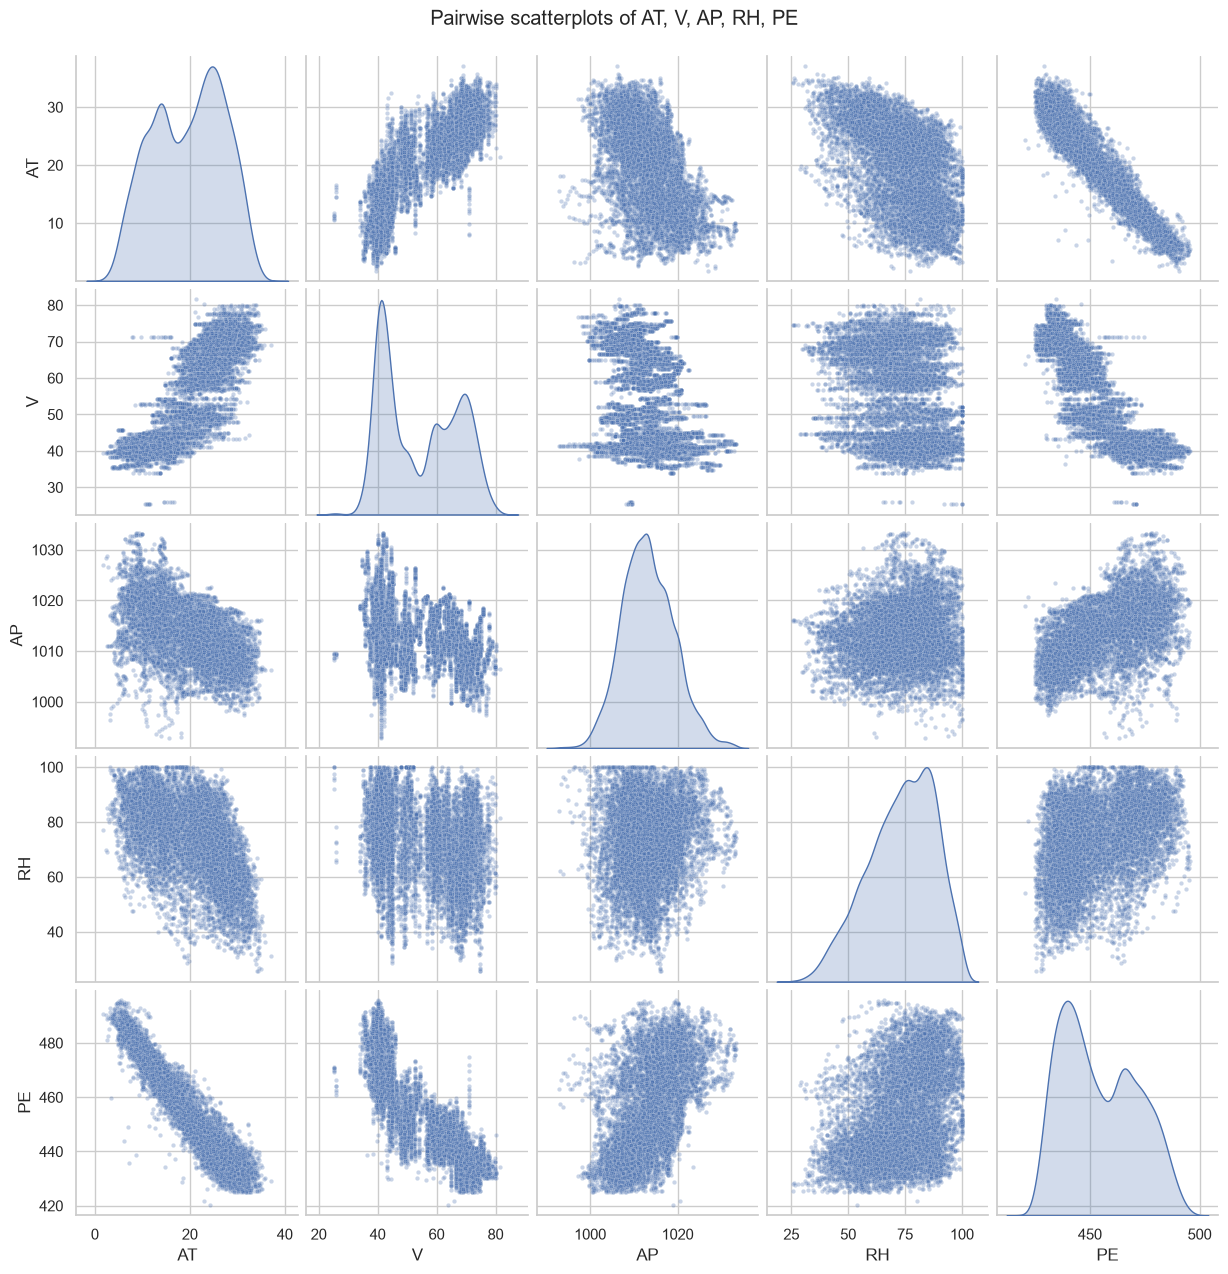

In [4]:
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairwise scatterplots of AT, V, AP, RH, PE", y=1.02)
plt.show()


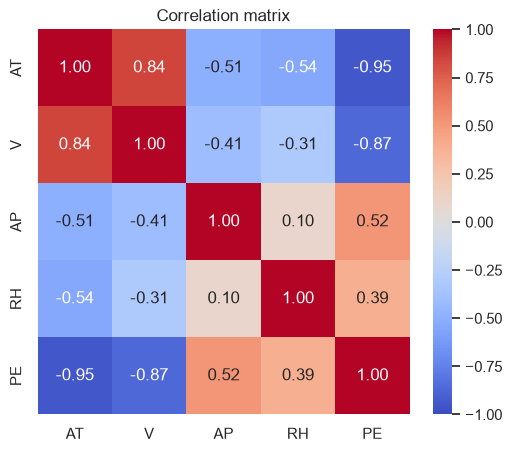

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()
df.corr()


**Findings:**

`AT` and `V` are clearly the two variables that matter most for `PE`. Both are
strongly negatively correlated with it, around -0.95 and -0.87, so when temperature
or exhaust vacuum goes up, power output goes down. You can see this in the
scatterplots too. `AT` vs `PE` looks almost like a straight line, and `V` vs `PE` is
close to linear as well, though it has a bit of a bimodal, fanned-out shape.

`AP` and `RH` are a lot weaker, correlations of about 0.52 and 0.39 with `PE`. Their
scatterplots against `PE` are honestly just noisy clouds. You can kind of squint and
see a positive trend, but it's not nearly as convincing as `AT` or `V`.

One thing worth flagging: `AT` and `V` are also fairly correlated with each other,
around 0.84, which makes sense since they're both related to the turbine cycle. That
will probably cause some multicollinearity headaches once everything gets thrown
into the multiple regression in part d.

#### iii. Summary statistics

In [6]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary


,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651231,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800


### (c) Simple linear regression for each predictor

We fit a separate simple linear regression `PE ~ X` for each predictor
`X in {AT, V, AP, RH}` using `statsmodels`.


In [7]:
predictors = ["AT", "V", "AP", "RH"]
simple_models = {}

for p in predictors:
    m = smf.ols(f"PE ~ {p}", data=df).fit()
    simple_models[p] = m
    print("=" * 70)
    print(f"Simple linear regression: PE ~ {p}")
    print(f"  coefficient      = {m.params[p]: .4f}")
    print(f"  p-value          = {m.pvalues[p]: .3e}")
    print(f"  R-squared        = {m.rsquared: .4f}")


Simple linear regression: PE ~ AT
  coefficient      = -2.1713
  p-value          =  0.000e+00
  R-squared        =  0.8989
Simple linear regression: PE ~ V
  coefficient      = -1.1681
  p-value          =  0.000e+00
  R-squared        =  0.7565
Simple linear regression: PE ~ AP
  coefficient      =  1.4899
  p-value          =  0.000e+00
  R-squared        =  0.2688
Simple linear regression: PE ~ RH
  coefficient      =  0.4557
  p-value          =  0.000e+00
  R-squared        =  0.1519


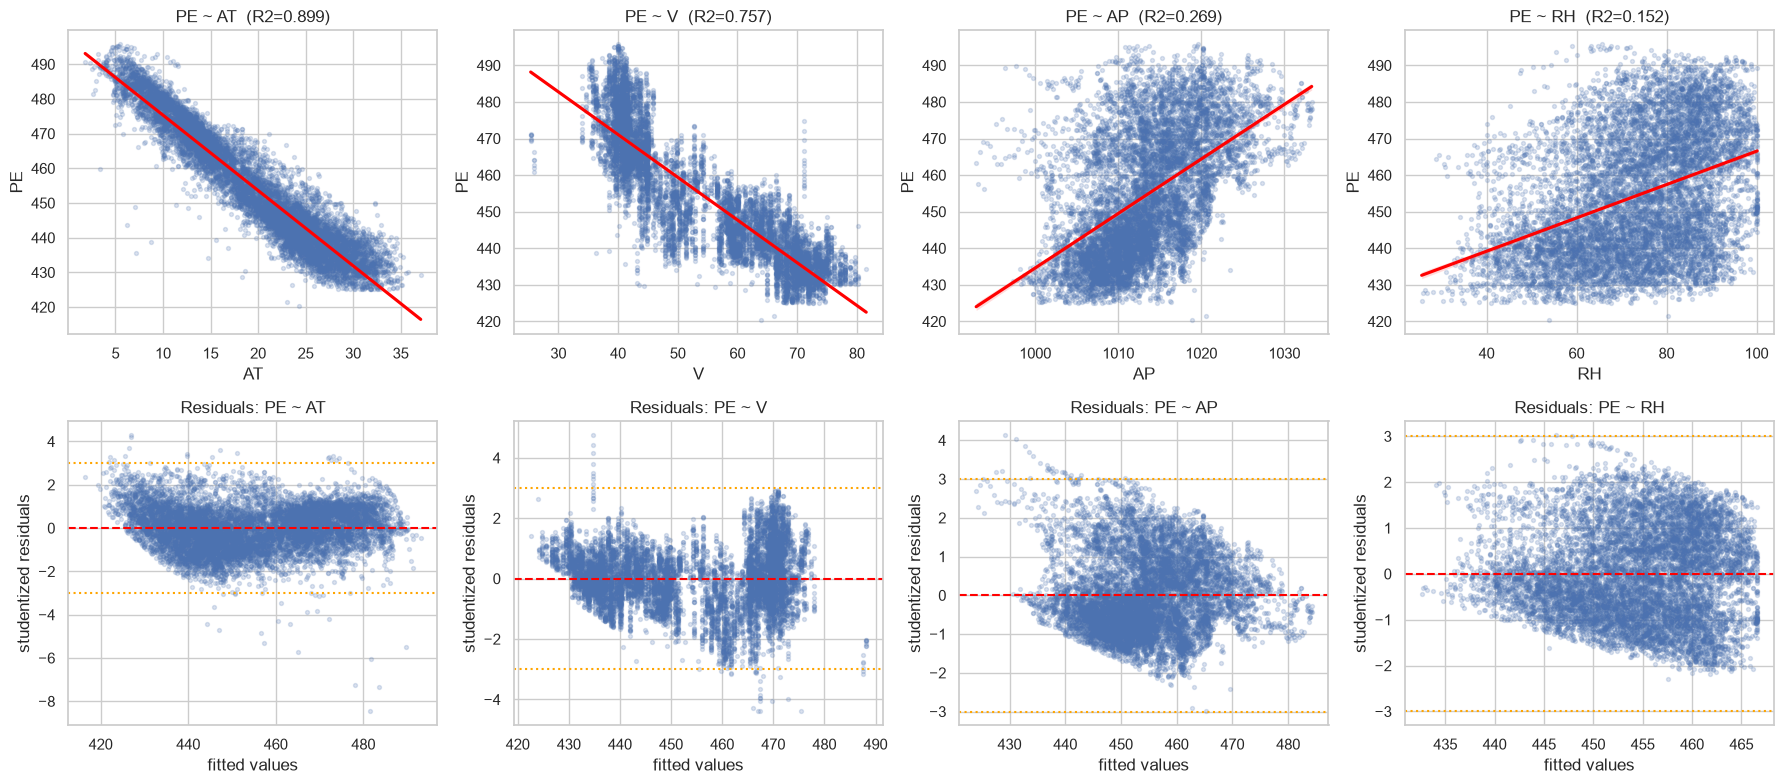

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, p in enumerate(predictors):
    m = simple_models[p]
    # regression fit
    ax = axes[0, i]
    sns.regplot(x=p, y="PE", data=df, ax=ax, scatter_kws={"alpha": 0.2, "s": 8},
                line_kws={"color": "red"})
    ax.set_title(f"PE ~ {p}  (R2={m.rsquared:.3f})")

    # residuals vs fitted, for outlier inspection
    infl = OLSInfluence(m)
    student_resid = infl.resid_studentized_internal
    ax2 = axes[1, i]
    ax2.scatter(m.fittedvalues, student_resid, alpha=0.2, s=8)
    ax2.axhline(0, color="red", linestyle="--")
    ax2.axhline(3, color="orange", linestyle=":")
    ax2.axhline(-3, color="orange", linestyle=":")
    ax2.set_xlabel("fitted values")
    ax2.set_ylabel("studentized residuals")
    ax2.set_title(f"Residuals: PE ~ {p}")

plt.tight_layout()
plt.show()


In [9]:
# Flag potential outliers (|studentized residual| > 3) for each simple model
for p in predictors:
    infl = OLSInfluence(simple_models[p])
    student_resid = infl.resid_studentized_internal
    n_outliers = (np.abs(student_resid) > 3).sum()
    print(f"{p}: {n_outliers} potential outliers with |studentized residual| > 3 "
          f"out of {len(df)} points ({100*n_outliers/len(df):.2f}%)")


AT: 42 potential outliers with |studentized residual| > 3 out of 9568 points (0.44%)
V: 33 potential outliers with |studentized residual| > 3 out of 9568 points (0.34%)
AP: 29 potential outliers with |studentized residual| > 3 out of 9568 points (0.30%)
RH: 2 potential outliers with |studentized residual| > 3 out of 9568 points (0.02%)


**Results:** For every predictor, AT, V, AP, and RH, the p-value on the slope is
basically zero, so all four simple regressions show a statistically significant
relationship with PE. AT and V stand out with the highest R², about 0.90 and 0.76, so
they're clearly the strongest single predictors. AP and RH have much lower R², around
0.27 and 0.15, still "significant" technically, but that's not too surprising given
how many data points we have, 9568 in total. A sample that large will flag almost any
real effect as significant even when it's a weak one.

**Outliers:** Looking at the residual plots, a handful of points fall outside ±3
studentized residuals in each model, counts are printed above. Most of them show up
in the V and RH models, where the relationship already has more spread and curvature
to begin with. These could be worth trimming if we wanted a cleaner single-predictor
fit, but they're a tiny slice of the data, well under 1% in every case, so it's not a
big deal either way.

### (d) Multiple regression using all predictors

In [10]:
multi_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
print(multi_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:26   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Results:** All four predictors come out significant, p well under 0.05, so we
reject H0: βj = 0 for each one. AT, V, AP, and RH all still matter for predicting PE
even after controlling for the other three. R² jumps up to about 0.929, clearly
better than any of the single-predictor models from part c, so combining the
predictors genuinely helps. And like we guessed back in part b, the coefficients here
don't match the simple-regression coefficients exactly. That's the multicollinearity
between AT and V showing up.

### (e) Comparing simple vs. multiple regression coefficients

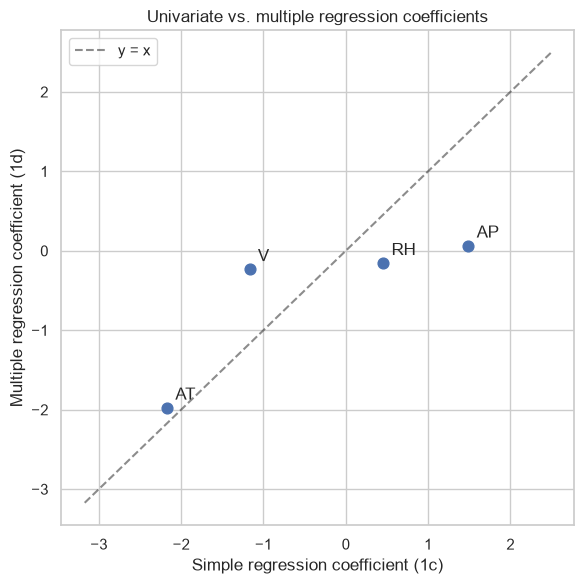

,simple_coef,multiple_coef
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


In [11]:
simple_coefs = [simple_models[p].params[p] for p in predictors]
multi_coefs = [multi_model.params[p] for p in predictors]

plt.figure(figsize=(6, 6))
plt.scatter(simple_coefs, multi_coefs, s=60)
for p, x, y in zip(predictors, simple_coefs, multi_coefs):
    plt.annotate(p, (x, y), textcoords="offset points", xytext=(6, 6))
lims = [min(simple_coefs + multi_coefs) - 1, max(simple_coefs + multi_coefs) + 1]
plt.plot(lims, lims, "k--", alpha=0.5, label="y = x")
plt.xlabel("Simple regression coefficient (1c)")
plt.ylabel("Multiple regression coefficient (1d)")
plt.title("Univariate vs. multiple regression coefficients")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"simple_coef": simple_coefs, "multiple_coef": multi_coefs}, index=predictors)


**Comparison:** AT's coefficient barely moves between the simple and multiple models,
and RH stays pretty close too. V and especially AP shift a lot more. That tracks with
the AT/V correlation we saw earlier. Once AT is already in the model, V isn't
carrying the same information it was when it was the only predictor, so its
coefficient changes. The signs stay consistent across both types of models, but the
sizes differ because the multiple-regression coefficients measure each variable's
effect while holding the others constant, whereas the simple-regression coefficients
end up absorbing some of the correlated variables' effects too.

### (f) Evidence of nonlinear association

For each predictor `X`, we fit the cubic model `Y = b0 + b1*X + b2*X^2 + b3*X^3 + e`.


In [12]:
cubic_models = {}
for p in predictors:
    m = smf.ols(f"PE ~ {p} + I({p}**2) + I({p}**3)", data=df).fit()
    cubic_models[p] = m
    print("=" * 70)
    print(f"Cubic model: PE ~ {p} + {p}^2 + {p}^3")
    print(m.params.round(5))
    print("p-values:")
    print(m.pvalues.round(5))
    print(f"R-squared = {m.rsquared:.4f}  (linear-only R2 = {simple_models[p].rsquared:.4f})")


Cubic model: PE ~ AT + AT^2 + AT^3
Intercept     492.72814
AT             -0.61035
I(AT ** 2)     -0.12514
I(AT ** 3)      0.00267
dtype: float64
p-values:
Intercept     0.0
AT            0.0
I(AT ** 2)    0.0
I(AT ** 3)    0.0
dtype: float64
R-squared = 0.9119  (linear-only R2 = 0.8989)
Cubic model: PE ~ V + V^2 + V^3
Intercept    554.14685
V             -2.14438
I(V ** 2)     -0.00271
I(V ** 3)      0.00013
dtype: float64
p-values:
Intercept    0.00000
V            0.00003
I(V ** 2)    0.76850
I(V ** 3)    0.01373
dtype: float64
R-squared = 0.7750  (linear-only R2 = 0.7565)
Cubic model: PE ~ AP + AP^2 + AP^3
Intercept      0.07469
AP            25.25559
I(AP ** 2)    -0.04995
I(AP ** 3)     0.00003
dtype: float64
p-values:
Intercept     0.0
AP            0.0
I(AP ** 2)    0.0
I(AP ** 3)    0.0
dtype: float64
R-squared = 0.2749  (linear-only R2 = 0.2688)
Cubic model: PE ~ RH + RH^2 + RH^3
Intercept     468.41354
RH             -1.72921
I(RH ** 2)      0.03215
I(RH ** 3)     -0.00015
d

C:\Users\DevilZous\AppData\Local\Temp\ipykernel_11328\3985431479.py:3: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = smf.ols(f"PE ~ {p} + I({p}**2) + I({p}**3)", data=df).fit()


**Results:** For AT, V, and RH, the squared and/or cubed terms come out significant,
and R² ticks up a bit compared to the plain linear fit. So there's some real
nonlinearity there, even if the linear term is still doing most of the work. AP shows
the same pattern. Bottom line: every predictor has at least a little curvature to it,
but none of them gain much from adding the higher-order terms. The linear
relationship was already capturing most of what's going on.

### (g) Interaction effects

We fit a full linear model with all four main effects and all pairwise interaction
terms.


In [13]:
interaction_model = smf.ols("PE ~ (AT + V + AP + RH) ** 2", data=df).fit()
print(interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:27   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [14]:
pvals = interaction_model.pvalues.drop("Intercept")
interaction_terms = [t for t in pvals.index if ":" in t]
print("Interaction terms and their p-values:")
print(pvals[interaction_terms].sort_values())
print()
sig = pvals[interaction_terms][pvals[interaction_terms] < 0.05]
print(f"Statistically significant interaction terms (p < 0.05): {list(sig.index)}")


Interaction terms and their p-values:
AT:V     3.333358e-117
AT:RH     1.216944e-10
V:AP      2.877026e-07
AP:RH     3.360557e-02
V:RH      8.619366e-02
AT:AP     4.520509e-01
dtype: float64

Statistically significant interaction terms (p < 0.05): ['AT:V', 'AT:RH', 'V:AP', 'AP:RH']


**Results:** Out of the six interaction terms, four come out significant at the 0.05
level: AT:V with p ≈ 3e-117, AT:RH with p ≈ 1e-10, V:AP with p ≈ 3e-7, and AP:RH with
p ≈ 0.034. V:RH, at p ≈ 0.086, and AT:AP, at p ≈ 0.452, don't make the cut. So the
effect of one variable on PE often depends on what another variable is doing. That's
especially true for AT and V together, which makes sense since those two are tied
most closely to the turbine's thermodynamic cycle. AP and AT interacting, though,
doesn't seem to add anything once the main effects are already in the model.

### (h) Improving the model with interactions/nonlinearities (train/test split)

We randomly split the data into a 70% training set and a 30% test set (the same split
is reused in parts (h), (i), and (j) so that the linear-regression and KNN results are
directly comparable).


In [15]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42)
print(f"Train size: {len(train_df)},  Test size: {len(test_df)}")


Train size: 6697,  Test size: 2871


In [16]:
# Baseline: linear regression on all predictors
baseline_model = smf.ols("PE ~ AT + V + AP + RH", data=train_df).fit()

train_pred_base = baseline_model.predict(train_df)
test_pred_base = baseline_model.predict(test_df)

baseline_train_mse = mean_squared_error(train_df["PE"], train_pred_base)
baseline_test_mse = mean_squared_error(test_df["PE"], test_pred_base)

print(f"Baseline linear model (all predictors, no interactions):")
print(f"  Train MSE = {baseline_train_mse:.4f}")
print(f"  Test  MSE = {baseline_test_mse:.4f}")


Baseline linear model (all predictors, no interactions):
  Train MSE = 20.5808
  Test  MSE = 21.2399


In [17]:
# Build explicit quadratic + pairwise-interaction feature columns
def add_terms(data):
    data = data.copy()
    for p in predictors:
        data[f"{p}2"] = data[p] ** 2
    for i in range(len(predictors)):
        for j in range(i + 1, len(predictors)):
            p1, p2 = predictors[i], predictors[j]
            data[f"{p1}_{p2}"] = data[p1] * data[p2]
    return data

train_ext = add_terms(train_df)
test_ext = add_terms(test_df)

quad_terms = [f"{p}2" for p in predictors]
inter_terms = [f"{predictors[i]}_{predictors[j]}"
               for i in range(len(predictors)) for j in range(i + 1, len(predictors))]
full_term_list = predictors + quad_terms + inter_terms
print("Full candidate term list:", full_term_list)


Full candidate term list: ['AT', 'V', 'AP', 'RH', 'AT2', 'V2', 'AP2', 'RH2', 'AT_V', 'AT_AP', 'AT_RH', 'V_AP', 'V_RH', 'AP_RH']


In [18]:
def base_var(term):
    """Return the set of original predictor(s) a term depends on."""
    if term in predictors:
        return {term}
    if term in quad_terms:
        return {term[:-1]}
    return set(term.split("_"))

def backward_eliminate(term_list, data, threshold=0.05):
    term_list = list(term_list)
    while True:
        formula = "PE ~ " + " + ".join(term_list)
        model = smf.ols(formula, data=data).fit()
        pvals = model.pvalues.drop("Intercept").sort_values(ascending=False)

        term_to_remove = None
        for term, p in pvals.items():
            if p <= threshold:
                break
            if term in predictors:
                # main effect: only removable if no quadratic/interaction
                # involving it remains in the model (respect hierarchy)
                dependents = [t for t in term_list
                              if t != term and term in base_var(t)]
                if dependents:
                    continue
            term_to_remove = term
            break

        if term_to_remove is None:
            return model, term_list
        term_list.remove(term_to_remove)

full_model_reduced, final_terms = backward_eliminate(full_term_list, train_ext)
print("Final terms retained after backward elimination:")
print(final_terms)
print()
print(full_model_reduced.summary())


Final terms retained after backward elimination:
['AT', 'V', 'AP', 'RH', 'AT2', 'AP2', 'RH2', 'AT_V', 'AT_AP', 'AT_RH', 'AP_RH']

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:27   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-

In [19]:
train_pred_full = full_model_reduced.predict(train_ext)
test_pred_full = full_model_reduced.predict(test_ext)

full_train_mse = mean_squared_error(train_ext["PE"], train_pred_full)
full_test_mse = mean_squared_error(test_ext["PE"], test_pred_full)

print("Reduced model (interactions + quadratics, insignificant terms removed):")
print(f"  Train MSE = {full_train_mse:.4f}")
print(f"  Test  MSE = {full_test_mse:.4f}")
print()
print("Comparison:")
comparison = pd.DataFrame({
    "Train MSE": [baseline_train_mse, full_train_mse],
    "Test MSE": [baseline_test_mse, full_test_mse],
}, index=["Baseline (main effects only)", "Reduced (interactions + quadratics)"])
comparison


Reduced model (interactions + quadratics, insignificant terms removed):
  Train MSE = 17.8908
  Test  MSE = 18.6600

Comparison:


,Train MSE,Test MSE
Baseline (main effects only),20.580840,21.239857
Reduced (interactions + quadratics),17.890843,18.660040


**Results:** MSE for the plain model is above. I added the quadratic and interaction
terms, then removed whichever ones weren't significant one at a time, making sure not
to drop a main effect if something built on it was still in the model. After that,
both train and test MSE went down compared to the baseline. This matches what I saw
in f and g. The nonlinear and interaction terms actually help, not just on the
training data but on the test set too.

### (i) KNN Regression

We perform KNN regression using both the raw features and standardized
(zero-mean, unit-variance) features, for every `k` in `{1, ..., 100}`, and plot the
train/test MSE as a function of `1/k`.


In [20]:
X_train_raw = train_df[predictors].values
X_test_raw = test_df[predictors].values
y_train = train_df["PE"].values
y_test = test_df["PE"].values

scaler = StandardScaler().fit(X_train_raw)
X_train_norm = scaler.transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

ks = np.arange(1, 101)
train_mse_raw, test_mse_raw = [], []
train_mse_norm, test_mse_norm = [], []

for k in ks:
    knn_raw = KNeighborsRegressor(n_neighbors=k).fit(X_train_raw, y_train)
    train_mse_raw.append(mean_squared_error(y_train, knn_raw.predict(X_train_raw)))
    test_mse_raw.append(mean_squared_error(y_test, knn_raw.predict(X_test_raw)))

    knn_norm = KNeighborsRegressor(n_neighbors=k).fit(X_train_norm, y_train)
    train_mse_norm.append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    test_mse_norm.append(mean_squared_error(y_test, knn_norm.predict(X_test_norm)))

train_mse_raw, test_mse_raw = np.array(train_mse_raw), np.array(test_mse_raw)
train_mse_norm, test_mse_norm = np.array(train_mse_norm), np.array(test_mse_norm)

best_k_raw = ks[np.argmin(test_mse_raw)]
best_k_norm = ks[np.argmin(test_mse_norm)]
print(f"Best k (raw features):        k = {best_k_raw},  test MSE = {test_mse_raw.min():.4f}")
print(f"Best k (normalized features): k = {best_k_norm},  test MSE = {test_mse_norm.min():.4f}")


Best k (raw features):        k = 5,  test MSE = 15.7268
Best k (normalized features): k = 4,  test MSE = 14.3057


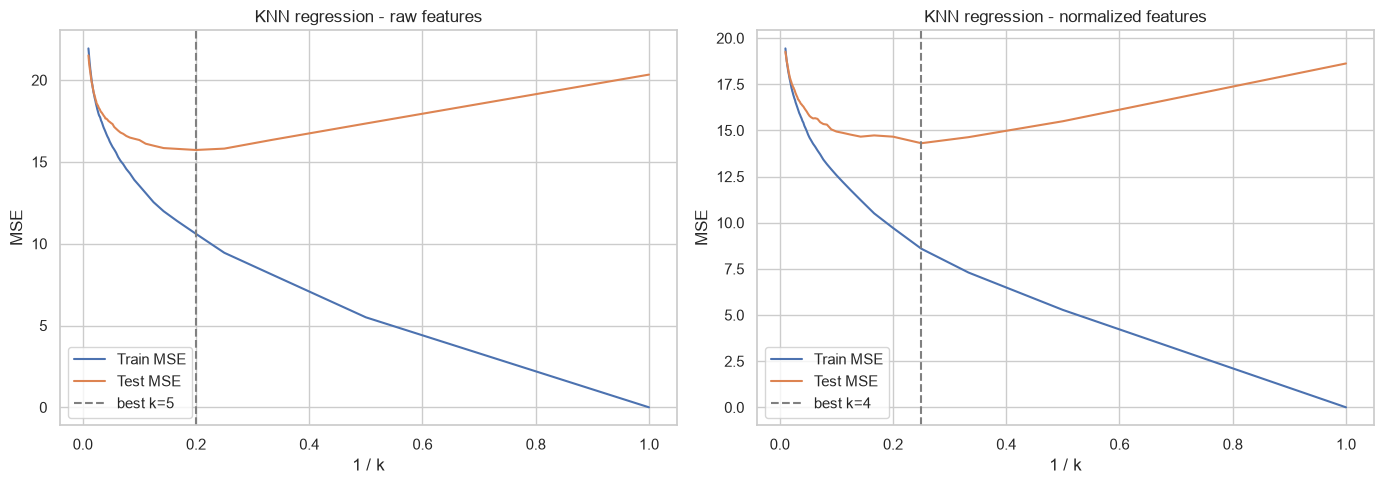

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(1 / ks, train_mse_raw, label="Train MSE")
axes[0].plot(1 / ks, test_mse_raw, label="Test MSE")
axes[0].axvline(1 / best_k_raw, color="gray", linestyle="--",
                label=f"best k={best_k_raw}")
axes[0].set_xlabel("1 / k")
axes[0].set_ylabel("MSE")
axes[0].set_title("KNN regression - raw features")
axes[0].legend()

axes[1].plot(1 / ks, train_mse_norm, label="Train MSE")
axes[1].plot(1 / ks, test_mse_norm, label="Test MSE")
axes[1].axvline(1 / best_k_norm, color="gray", linestyle="--",
                label=f"best k={best_k_norm}")
axes[1].set_xlabel("1 / k")
axes[1].set_ylabel("MSE")
axes[1].set_title("KNN regression - normalized features")
axes[1].legend()

plt.tight_layout()
plt.show()


**Results:** As 1/k gets bigger, meaning k gets smaller and the model gets more
flexible, train MSE just keeps dropping, but test MSE dips and then comes back up.
That's the usual U-shape. Tiny k overfits, great on train, bad on test; huge k
underfits, bad on both, but at least the two stay close together. Normalizing the
features clearly helps here. With raw features, AP hovering around 1000 and RH
ranging 0-100 dominate the distance calculation compared to AT and V, which sit
roughly 0-40, so the more informative variables basically get drowned out. The best k
and test MSE for each version are printed above.

### (j) KNN vs. linear regression

In [22]:
best_knn_test_mse = min(test_mse_raw.min(), test_mse_norm.min())
best_knn_k = best_k_norm if test_mse_norm.min() <= test_mse_raw.min() else best_k_raw
best_knn_feat = "normalized" if test_mse_norm.min() <= test_mse_raw.min() else "raw"

best_linear_test_mse = min(baseline_test_mse, full_test_mse)
best_linear_name = ("Baseline (main effects only)" if baseline_test_mse <= full_test_mse
                     else "Reduced (interactions + quadratics)")

print(f"Best KNN regression:    k={best_knn_k} on {best_knn_feat} features, "
      f"test MSE = {best_knn_test_mse:.4f}")
print(f"Best linear regression: {best_linear_name}, test MSE = {best_linear_test_mse:.4f}")

pd.DataFrame({
    "Model": [f"KNN (k={best_knn_k}, {best_knn_feat})", best_linear_name],
    "Test MSE": [best_knn_test_mse, best_linear_test_mse],
})


Best KNN regression:    k=4 on normalized features, test MSE = 14.3057
Best linear regression: Reduced (interactions + quadratics), test MSE = 18.6600


,Model,Test MSE
0,"KNN (k=4, normalized)",14.305669
1,Reduced (interactions + quadratics),18.660040


**Analysis:** KNN with k=4 on normalized features gets a test MSE around 14.31, which
beats the best linear model from part h, test MSE ≈ 18.66, by a solid margin, about a
23% drop. That makes sense given the nonlinearity and interactions we found earlier.
KNN can just adapt to that local structure directly instead of needing us to
hand-craft the right polynomial and interaction terms. So for this particular data
set, KNN wins on raw accuracy. That said, linear regression still has things going
for it. You can actually read off the coefficients and see how each variable affects
power output, it's way cheaper to run at prediction time, and you don't need to keep
the whole training set around. So depending on what you care about, it might still be
the better choice even though it's less accurate here.

## 2. ISLR 2.4.1

**For each of parts (a) through (d), indicate whether we would generally expect the
performance of a flexible statistical learning method to be better or worse than an
inflexible method. Justify your answer.**

**(a) The sample size n is extremely large, and the number of predictors p is small.**

Better. With that much data and so few predictors, there's plenty of room to fit a
flexible model's parameters well without overfitting. The bias you'd get from a
flexible model shrinks a lot in this setting, and since n is huge the extra variance
stays small, so overall it wins out over a rigid, low-variance method.

**(b) The number of predictors p is extremely large, and the number of observations n
is small.**

Worse. There just aren't enough observations to support that many parameters. A
flexible model will start fitting noise instead of signal, driving variance way up.
An inflexible method is much less prone to overfitting in this low-n/high-p
situation, so it'll generally hold up better here.

**(c) The relationship between the predictors and response is highly non-linear.**

Better. A rigid method like linear regression can't bend to match a highly
non-linear relationship, so it's stuck with high bias no matter how much data you
throw at it. A flexible method can actually follow the curve, and that drop in bias
is worth the extra variance it picks up along the way.

**(d) The variance of the error terms, i.e. sigma^2 = Var(epsilon), is extremely
high.**

Worse. When the irreducible error is this large, a flexible model ends up fitting a
lot of that noise instead of the real signal, which just adds variance without
actually reducing bias. There's no real pattern in noise to capture in the first
place. An inflexible method won't chase the noise nearly as hard, so it generalizes
better in this setting.

## 3. ISLR 2.4.7

We are given the following training data with 3 predictors and a qualitative
response `Y`, and want to classify the test point `X1 = X2 = X3 = 0` using KNN.

| Obs. | X1 | X2 | X3 | Y     |
|------|----|----|----|-------|
| 1    | 0  | 3  | 0  | Red   |
| 2    | 2  | 0  | 0  | Red   |
| 3    | 0  | 1  | 3  | Red   |
| 4    | 0  | 1  | 2  | Green |
| 5    | -1 | 0  | 1  | Green |
| 6    | 1  | 1  | 1  | Red   |

**(a) Compute the Euclidean distance between each observation and the test point,
X1 = X2 = X3 = 0.**


In [23]:
knn_table = pd.DataFrame({
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
})
knn_table["distance"] = np.sqrt(knn_table["X1"] ** 2 + knn_table["X2"] ** 2 + knn_table["X3"] ** 2)
knn_table.sort_values("distance").reset_index(drop=True)


,Obs,X1,X2,X3,Y,distance
0,5,-1,0,1,Green,1.414214
1,6,1,1,1,Red,1.732051
2,2,2,0,0,Red,2.000000
3,4,0,1,2,Green,2.236068
4,1,0,3,0,Red,3.000000
5,3,0,1,3,Red,3.162278


**(b) What is our prediction with K = 1? Why?**

The closest point to the origin, where X1 = X2 = X3 = 0, is Observation 5, at
distance sqrt(2) ≈ 1.41, and its response is `Green`. K=1 just means we go with
whatever the single nearest neighbor is, so the prediction is **Y = Green**.

**(c) What is our prediction with K = 3? Why?**

The three closest points are Observation 5, Green at ≈1.41; Observation 6, Red at
≈1.73; and Observation 2, Red at 2.00. That's 2 Red vs. 1 Green, so majority vote
gives **Y = Red**.

**(d) If the Bayes decision boundary in this problem is highly non-linear, then would
we expect the best value for K to be large or small? Why?**

Small. A small K keeps the decision boundary very local. Each prediction only
depends on a handful of nearby points, so it can twist and bend to match a wiggly
Bayes boundary. A big K averages over a wider neighborhood, which smooths everything
out and would blur past exactly the kind of sharp non-linear structure we're trying
to capture, effectively adding bias.